# Week 7: Evaluations
### Author: Rajit Rajpal
The goal of this tutorial will be to learn about evaluations of images `# TODO` are for you to implement. Solutions will contain the completed code. We will be evaluating samples from a GAN and a VAE.

### Imports

In [ ]:
# %pip install numpy matplotlib torch torchvision lpips scipy pillow scikit-learn
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from scipy.linalg import sqrtm
import torchvision.transforms.functional as TF

# Import architectures
from vae import VAE
from gan import Generator as GAN_Generator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set seed
torch.manual_seed(42)
np.random.seed(42)

# Load Models
vae = VAE().to(device)
vae.load_state_dict(torch.load("vae_mnist.pth", map_location=device))
vae.eval()

gan = GAN_Generator().to(device)
gan.load_state_dict(torch.load("gan_mnist.pth", map_location=device))
gan.eval()

# Data Preparation
transform = transforms.Compose([transforms.ToTensor()])
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Models loaded on {device}. Ready for evaluation.")

Models loaded on cpu. Ready for evaluation.


### Custom Feature Extractor

There are a myriad of evaluation metrics for images. The simplest ones are pairwise metrics which compute the similarity between 2 images. This is useful for "data-to-data" tasks such as reconstruction, but not very useful for generative modeling where we do not have paired reference images to compare against directly. Examples of paired reference metrics include MSE (mean squared error) and LPIPS (Learned Perceptual Image Patch Similarity). The former is a simple MSE in pixel space 

$$
\mathrm{MSE}(x, y) = \frac{1}{N} \sum_{i=1}^{N} (x_i - y_i)^2
$$

whilst the latter is done in the feature space of a pretrained network that has been trained on millions of natural images. 

$$
\mathrm{LPIPS}(x, y) =
\sum_{l} \frac{1}{H_l W_l}
\sum_{h,w}
\left\|
w_l \odot
\left(
\hat{f}_l(x)_{hw} - \hat{f}_l(y)_{hw}
\right)
\right\|_2^2
$$

They performed classification using these images, and then removed the classification head to get these features. 

For unpaired metrics, the most popular one is Frechet Inception Distance (FID). Thousands of real and generated images are encoded into the feature space of a pretrained network (Inception-V3), embedded as Gaussians, and then evaluated with the formulae below:

$$
\mathrm{FID} = \left\| \mu_r - \mu_g \right\|_2^2
+ \mathrm{Tr}\left( \Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{\frac{1}{2}} \right)
$$

The following exercise will have you train your own simple classifier for MNIST and use it as a feature extractor for computing LPIPS and FID later.

In [35]:
class MNISTJudge(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1: Low-level edges
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2)
        )
        # Layer 2: Higher-level shapes
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2)
        )
        # GAP Layer: Reduces (64, 7, 7) -> (64, 1, 1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

judge = MNISTJudge().to(device)
optimizer = optim.Adam(judge.parameters(), lr=1e-3)
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False)

print("Training Custom Feature Extractor with GAP...")
for epoch in range(3):
    judge.train()
    train_loss = 0
    for imgs, labels in DataLoader(datasets.MNIST('./data', train=True, transform=transform), batch_size=128, shuffle=True):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        output = judge(imgs)
        loss = nn.functional.cross_entropy(output, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Final Accuracy Check per Epoch
    judge.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = judge(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Test Acc: {accuracy:.2f}%")

print("Judge trained and verified.")

Training Custom Feature Extractor with GAP...
Epoch 1 | Loss: 1.7104 | Test Acc: 59.32%
Epoch 2 | Loss: 1.0557 | Test Acc: 74.78%
Epoch 3 | Loss: 0.7754 | Test Acc: 81.85%
Judge trained and verified.


### Discussion:
Not bad but you could train for longer to get a higher test accuracy and therefore a better feature extractor. You could also use a larger network with architectural adaptations, data augmentation, hyperparameter tuning etc.

### LPIPS and MSE on VAE reconstruction

MSE is known to be relatively insensitive to blur and highly sensitive to translations, both of which would be undesirable as they do not correspond to human visual perception for obvious reasons. Features extracted will generally be more sensitive to blur and insensitive to translation if it has convolutional layers (as they impose translation invariant inductive biases). VAEs are known to be highly blurry due to mode coverage due to the prior imposed.

In [36]:
def get_custom_lpips(x1, x2, model):
    model.eval()
    with torch.no_grad():
        # Layer 1 features
        f1_x1, f1_x2 = model.conv1(x1), model.conv1(x2)
        # Layer 2 features
        f2_x1, f2_x2 = model.conv2(f1_x1), model.conv2(f1_x2)
        
        # Aggregate distance across feature hierarchies
        dist = torch.mean((f1_x1 - f1_x2)**2) + torch.mean((f2_x1 - f2_x2)**2)
        return dist.item()

# Evaluation on VAE Reconstructions
real_batch, _ = next(iter(test_loader))
real_batch = real_batch.to(device)

# Unpack the tuple! VAE returns (reconstruction, mu, logvar)
vae_output = vae(real_batch)
if isinstance(vae_output, tuple):
    vae_recons = vae_output[0]
else:
    vae_recons = vae_output

# Ensure the shape is (B, 1, 28, 28) if the VAE flattened it
vae_recons = vae_recons.view(-1, 1, 28, 28)

mse_score = torch.mean((real_batch - vae_recons)**2).item()
lpips_score = get_custom_lpips(real_batch, vae_recons, judge)

print(f"VAE Performance -> MSE (Pixel): {mse_score:.6f} | LPIPS (Perceptual): {lpips_score:.6f}")

VAE Performance -> MSE (Pixel): 0.013396 | LPIPS (Perceptual): 3.210391


Below is an example where we evaluate how sensitive MSE and LPIPS are to blur and translation invariance, respectively.

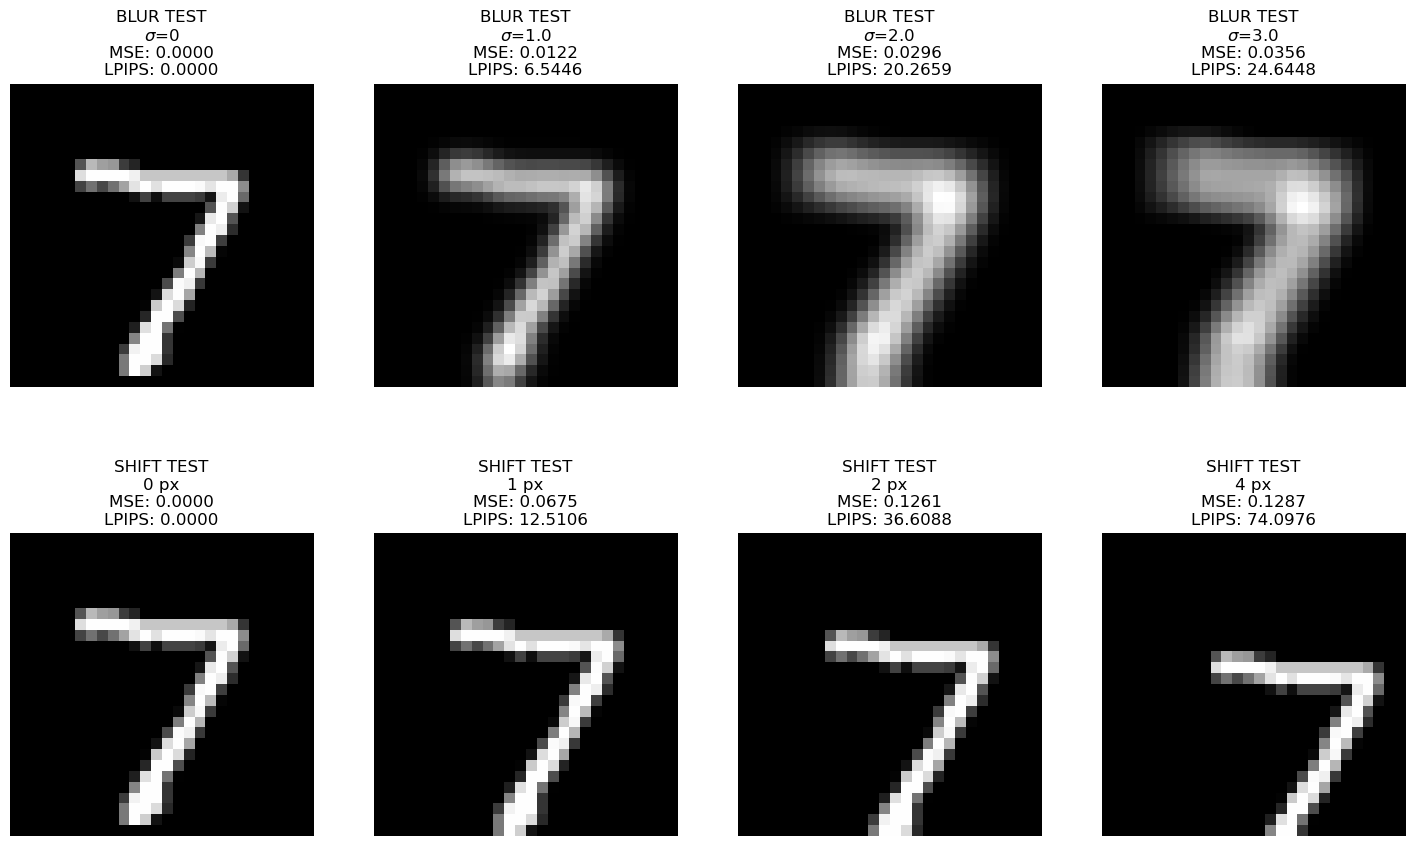

In [37]:
def evaluate_sensitivity(img, model_fe):
    sigmas = [0, 1.0, 2.0, 3.0]
    shifts = [0, 1, 2, 4]
    
    # Increase figsize and adjust hspace for better heading visibility
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    plt.subplots_adjust(hspace=0.4) 
    
    # 1. Blur Test
    for i, s in enumerate(sigmas):
        blurred = TF.gaussian_blur(img, kernel_size=(7, 7), sigma=s) if s > 0 else img
        mse = torch.mean((img - blurred)**2).item()
        lpips = get_custom_lpips(img, blurred, model_fe)
        
        axes[0, i].imshow(blurred[0,0].cpu(), cmap='gray')
        axes[0, i].set_title(f"BLUR TEST\n$\sigma$={s}\nMSE: {mse:.4f}\nLPIPS: {lpips:.4f}", fontsize=12)
        axes[0, i].axis('off')

    # 2. Translation Test
    for i, shift in enumerate(shifts):
        shifted = torch.roll(img, shifts=(shift, shift), dims=(2, 3))
        if shift > 0:
            shifted[:, :, :shift, :] = 0
            shifted[:, :, :, :shift] = 0
            
        mse = torch.mean((img - shifted)**2).item()
        lpips = get_custom_lpips(img, shifted, model_fe)
        
        axes[1, i].imshow(shifted[0,0].cpu(), cmap='gray')
        axes[1, i].set_title(f"SHIFT TEST\n{shift} px\nMSE: {mse:.4f}\nLPIPS: {lpips:.4f}", fontsize=12)
        axes[1, i].axis('off')

    plt.show()

# Run the test on a single digit from the test set
sample_digit = real_batch[0:1] # Picking a sharp '0' or '4' is usually illustrative
evaluate_sensitivity(sample_digit, judge)

### Discussion: 
Note that MSE is upper-bounded by the pixel-intensity, so 0.12 would be about as high as it gets. You could also train the feature extractor on augmented data for example with noise added or with translations imposed. This would achieve the desired results more strongly and give us a robust metric!

### FID on GAN samples

Finally, we will compute FID on our GAN samples. GANs are know to generate sharp images but often mode collapsed so it does not have good diversity and may have artifacts due to training instability. We need to generate 2048 such samples at a minimum to get a reliable FID estimate. Too few would not make sense since the data is unpaired.

In [38]:
def calculate_fid(model, loader, mode='real', gen_model=None, num_samples=2048):
    model.eval()
    features = []
    count = 0
    with torch.no_grad():
        for x, _ in loader:
            if count >= num_samples: break
            if mode == 'real':
                inputs = x.to(device)
            else:
                z = torch.randn(x.size(0), 100).to(device)
                inputs = (gen_model(z) + 1) / 2 # Scale GAN to [0, 1]
            
            # Use flattened conv2 output as the feature vector
            feat = torch.flatten(model.conv2(model.conv1(inputs)), 1)
            features.append(feat.cpu().numpy())
            count += x.size(0)
    
    feats = np.concatenate(features)
    mu, sigma = feats.mean(axis=0), np.cov(feats, rowvar=False)
    return mu, sigma

def fid_formula(mu1, sigma1, mu2, sigma2):
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean): covmean = covmean.real
    return ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)

# Comparison
mu_r, sig_r = calculate_fid(judge, test_loader, mode='real')
mu_g, sig_g = calculate_fid(judge, test_loader, mode='gan', gen_model=gan)

mnist_fid = fid_formula(mu_r, sig_r, mu_g, sig_g)
print(f"Custom MNIST-FID: {mnist_fid:.4f}")

Custom MNIST-FID: 21572.6261


### Discussion: 
As expected, the FID is very high. Our GAN was not well-trained due to instbailities resulting in artifacts and blobby generations. But it is still sharp atleast :p 
An interesting exercise would be to see if you can modify gan.py (either configurations or even architecture) and obtain better samples, resulting in better FIDs.